## SETTING UP THE ENVIRONMENT
- First we Install the appropriate libraries and packages

In [1]:
!pip install pandas --quiet
!pip install numpy --quiet
!pip install seaborn --quiet
!pip install matplotlib --quiet
%pip install scikit-learn --quiet


Note: you may need to restart the kernel to use updated packages.


- Then we Imprt the necesary libraries

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline

## To Improve Styles and the Chart Font Sizes

In [3]:
sns.set_style('darkgrid')
matplotlib.rcParams['font.size']==14
matplotlib.rcParams['figure.figsize']=(10,6)
matplotlib.rcParams['figure.facecolor']= '00000000'

## Import, Read and Store Data into a Data Frame called Medical_DF

In [7]:
medical_df = pd.read_csv(r"C:\Users\Gifton\Videos\0.0002 DATA ANALYTICS\103_MACHINE_LEARNING\PROJECT_A\medical_insurance_cost_dataset.csv")
medical_df.sample(2)

,customer_id,age,gender,bmi,children,smoker,region,occupation,annual_income_usd,exercise_level,chronic_diseases,doctor_visits_per_year,hospitalizations_last_year,alcohol_consumption_per_week,insurance_plan,annual_medical_cost_usd
2892,MIC102893,34,Male,28.0,2,No,Central,Technician,30434,Low,0,6,0,9,Basic,11159.02
2027,MIC102028,63,Male,28.4,2,No,Southwest,Driver,18000,Low,1,10,0,10,Standard,18047.04


## Create a Copy of The Dataset
- Creating a copy of the dataset is Necessary incase of Any errors made that may affect the original data

In [8]:
medical_2 = medical_df.copy()
medical_2.sample(2)

,customer_id,age,gender,bmi,children,smoker,region,occupation,annual_income_usd,exercise_level,chronic_diseases,doctor_visits_per_year,hospitalizations_last_year,alcohol_consumption_per_week,insurance_plan,annual_medical_cost_usd
3517,MIC103518,49,Female,25.2,1,No,Southwest,Retail Worker,63576,Moderate,0,6,0,5,Premium,12742.50
2079,MIC102080,37,Female,30.2,2,Yes,Central,Construction Worker,35934,Moderate,0,2,0,1,Standard,26236.85


## Understanding and Data Cleaning.
- Must obtain a quality report first to understand how our data looks like, check for shapes and size
- This data is checked for all forms of inconsistencies such as Missing values, duplicates etc

In [10]:
def data_quality_check(medical_2) :
    info_report = {
        'shape':medical_2.shape,
        'total_records':len(medical_2),
        'duplicate_records':medical_2.duplicated().sum(),
        'missing_records': medical_2.isnull().sum(),
    }
    return info_report
info_report = data_quality_check(medical_2)
print(info_report)
        
                   


{'shape': (7500, 16), 'total_records': 7500, 'duplicate_records': np.int64(0), 'missing_records': customer_id                     0
age                             0
gender                          0
bmi                             0
children                        0
smoker                          0
region                          0
occupation                      0
annual_income_usd               0
exercise_level                  0
chronic_diseases                0
doctor_visits_per_year          0
hospitalizations_last_year      0
alcohol_consumption_per_week    0
insurance_plan                  0
annual_medical_cost_usd         0
dtype: int64}


## Reporting on Data Quality Check:
- The data comprises of 7500 rows and 16 columns
- There are no duplicates records
- There are no null/ missing values.

The data is clean and hence we can explore the data further.

## Check for the data types
- These tell us if the values in each of the columns are represented accordingly

In [11]:
medical_2.dtypes

customer_id                      object
age                               int64
gender                           object
bmi                             float64
children                          int64
smoker                           object
region                           object
occupation                       object
annual_income_usd                 int64
exercise_level                   object
chronic_diseases                  int64
doctor_visits_per_year            int64
hospitalizations_last_year        int64
alcohol_consumption_per_week      int64
insurance_plan                   object
annual_medical_cost_usd         float64
dtype: object

In [12]:
medical_2.head(2)

,customer_id,age,gender,bmi,children,smoker,region,occupation,annual_income_usd,exercise_level,chronic_diseases,doctor_visits_per_year,hospitalizations_last_year,alcohol_consumption_per_week,insurance_plan,annual_medical_cost_usd
0,MIC100001,56,Male,25.2,2,Yes,Northeast,Driver,77885,Moderate,0,2,0,13,Basic,24353.46
1,MIC100002,29,Male,25.7,1,Yes,Northwest,Doctor,18000,High,0,2,0,3,Standard,22530.60


## Define our numerical Columns Vs Categorical Columns
- Numerical Columns consist of Integer and Float Data Type.
- Categorical Columns consist of Object Data Type.

In [18]:
numerical_cols = medical_2.select_dtypes(include=['int64', 'float64'])
numerical_cols

,age,bmi,children,annual_income_usd,chronic_diseases,doctor_visits_per_year,hospitalizations_last_year,alcohol_consumption_per_week,annual_medical_cost_usd
0,56,25.2,2,77885,0,2,0,13,24353.46
1,29,25.7,1,18000,0,2,0,3,22530.60
2,20,30.1,1,85811,1,5,0,1,13393.16
3,59,18.2,1,18000,2,10,0,8,17937.26
4,61,31.2,5,42331,0,7,0,13,22147.64
...,...,...,...,...,...,...,...,...,...
7495,54,19.6,3,91504,0,5,0,12,11088.39
7496,22,19.8,0,66444,0,6,0,13,5319.79
7497,18,23.8,1,113178,2,7,1,12,17097.41
7498,47,33.2,0,85916,1,11,0,4,13223.05


In [20]:
categorical_cols = medical_2.select_dtypes(include=['object'])
categorical_cols

,customer_id,gender,smoker,region,occupation,exercise_level,insurance_plan
0,MIC100001,Male,Yes,Northeast,Driver,Moderate,Basic
1,MIC100002,Male,Yes,Northwest,Doctor,High,Standard
2,MIC100003,Male,No,Central,Teacher,Low,Standard
3,MIC100004,Female,No,Northeast,Engineer,Moderate,Premium
4,MIC100005,Male,Yes,Northwest,Nurse,Moderate,Standard
...,...,...,...,...,...,...,...
7495,MIC107496,Female,No,Northeast,Engineer,Moderate,Standard
7496,MIC107497,Male,No,Central,Lawyer,High,Standard
7497,MIC107498,Female,No,Northwest,Office Worker,Moderate,Standard
7498,MIC107499,Female,No,Southwest,Driver,Low,Basic


## Obtain Summary Statistics for our Column Category
- Numerical Vs Categorical Columns

In [24]:
numerical_stats = numerical_cols.describe()
numerical_stats

,age,bmi,children,annual_income_usd,chronic_diseases,doctor_visits_per_year,hospitalizations_last_year,alcohol_consumption_per_week,annual_medical_cost_usd
count,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000
mean,41.332400,28.054173,1.493867,65344.240000,0.704533,4.713067,0.343733,6.975467,17912.526807
std,13.913264,4.932231,1.210409,24728.459461,0.847110,2.290554,0.561209,4.298681,7574.460081
min,18.000000,16.000000,0.000000,18000.000000,0.000000,0.000000,0.000000,0.000000,1500.000000
25%,29.000000,24.600000,1.000000,47987.500000,0.000000,3.000000,0.000000,3.000000,12385.620000
50%,41.000000,28.000000,1.000000,65041.500000,1.000000,4.000000,0.000000,7.000000,16361.925000
75%,53.000000,31.500000,2.000000,82228.000000,1.000000,6.000000,1.000000,11.000000,22555.107500
max,65.000000,45.000000,5.000000,176977.000000,5.000000,15.000000,3.000000,14.000000,49332.680000


In [25]:
categorical_stats = categorical_cols.describe()
categorical_stats

,customer_id,gender,smoker,region,occupation,exercise_level,insurance_plan
count,7500,7500,7500,7500,7500,7500,7500
unique,7500,2,2,5,11,3,4
top,MIC100001,Male,No,Northwest,Technician,Moderate,Standard
freq,1,3767,6029,1562,705,3705,3007


## During this Analysis project, we would love to explore:
- The Contributing Factors that affect Patients Annual Medical Cost
- How the Annual Medical Cost is affected by factors such as age, bmi,children,annual_income_usd,chronic_diseases,doctor_visits_per_year, hospitalizations_last_year and alcohol_consumption_per_week,gender,smoker,region,occupation,exercise_level andinsurance_plan

## AA. How is the annual medical cost distributed? Is it skewed?
- Why this matters: Medical costs are rarely "normal" (they usually skew right due to a few very expensive patients). Knowing this tells you whether to use mean/median and whether you might need to log-transform later.
  

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['annual_medical_cost_usd'], bins=30, kde=True)
plt.title('Distribution of Annual Medical Costs')
plt.xlabel('Cost (USD)')
plt.show()

## AB.  Does smoking status or chronic diseases dramatically shift the average cost?
- Why this matters: This is the classic "split-by-category" question. Smokers and chronically ill patients are expected to have higher costs. A simple boxplot instantly proves (or disproves) your strongest hypothesis.

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='smoker', y='annual_medical_cost_usd', data=df)
plt.title('Medical Cost by Smoking Status')
plt.show()

AAC. Do age and BMI show clear linear trends with increasing medical costs?
- Why this matters: This checks your numeric relationships. A scatter plot with a regression line helps you see if costs steadily rise as people get older or heavier, or if the relationship is flat/non-linear.

In [ ]:
# Scatter plot for Age
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.regplot(x='age', y='annual_medical_cost_usd', data=df, scatter_kws={'alpha':0.3})
plt.title('Age vs Cost')

# Scatter plot for BMI
plt.subplot(1,2,2)
sns.regplot(x='bmi', y='annual_medical_cost_usd', data=df, scatter_kws={'alpha':0.3})
plt.title('BMI vs Cost')
plt.tight_layout()
plt.show()

# Get the correlation coefficients (Pearson)
print(f"Correlation Age-Cost: {df['age'].corr(df['annual_medical_cost_usd']):.3f}")
print(f"Correlation BMI-Cost: {df['bmi'].corr(df['annual_medical_cost_usd']):.3f}")

## AAD Which numeric factors have the strongest correlation with medical costs?
- Why this matters: You have many numeric columns (children, income, doctor_visits, hospitalizations, alcohol). A single heatmap visualizes all relationships at once, letting you rank which ones affect annual_medical_cost_usd the most.

In [ ]:
# Select only numeric columns
numeric_cols = ['age', 'bmi', 'children', 'annual_income_usd', 'doctor_visits_per_year', 
                'hospitalizations_last_year', 'alcohol_consumption_per_week', 'annual_medical_cost_usd']

corr_matrix = df[numeric_cols].corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

# Specifically, sort features by their correlation with the target
print(corr_matrix['annual_medical_cost_usd'].sort_values(ascending=False))

##  How does the combination of Region and Insurance Plan affect average costs?
- Why this matters: Individual factors might hide interaction effects. For example, a specific plan might be expensive in one region but cheap in another. Grouped bar charts or pivot tables reveal these patterns before you build a full model.

In [ ]:
# Create a pivot table of average costs
pivot = pd.pivot_table(df, 
                       values='annual_medical_cost_usd', 
                       index='region', 
                       columns='insurance_plan', 
                       aggfunc='mean')

print(pivot)  # View the numbers

# Visualize it as a grouped bar chart
pivot.plot(kind='bar', figsize=(10, 6))
plt.title('Average Medical Cost by Region and Insurance Plan')
plt.ylabel('Average Cost (USD)')
plt.xlabel('Region')
plt.xticks(rotation=0)
plt.legend(title='Insurance Plan')
plt.tight_layout()
plt.show()

# You can swap 'region' with 'occupation' or 'exercise_level' to test other categorical pairs!

## A. hOW IS AGE distributed in the dataset

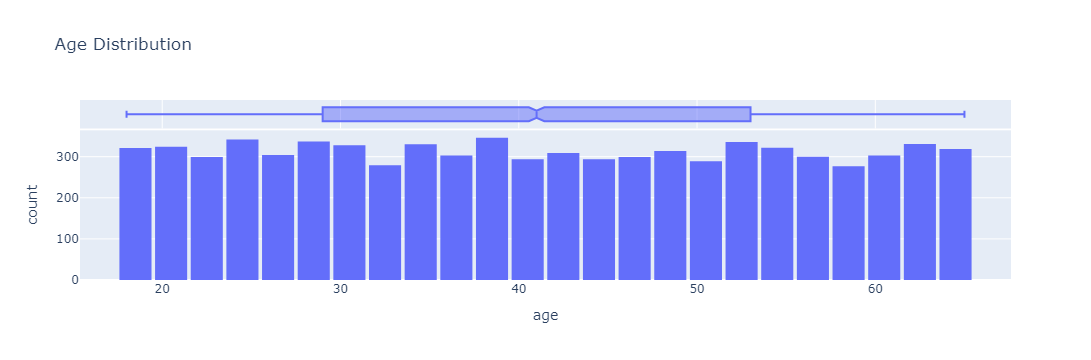

In [28]:
fig = px.histogram(medical_2, x='age', marginal='box',nbins=37,title='Age Distribution')
fig.update_layout(bargap=0.1)
fig.show()

## For the factor of bmi

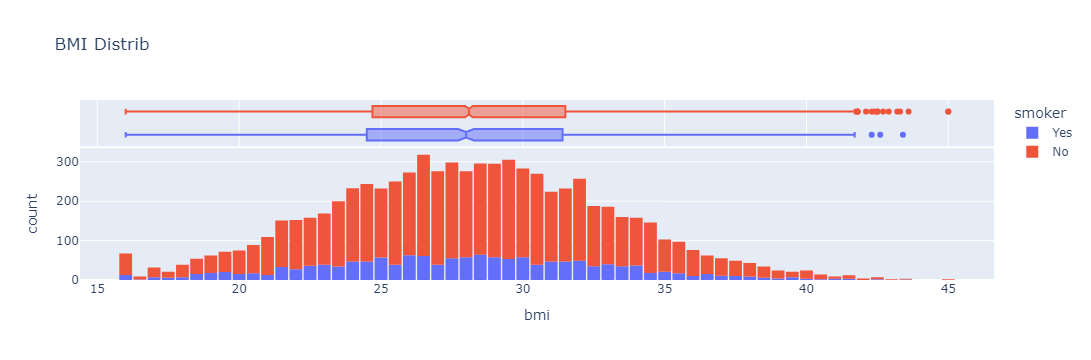

In [36]:
fig = px.histogram(medical_2, x='bmi', marginal ='box',color ='smoker',title='BMI Distrib')
fig.update_layout(bargap=0.1)
fig.show()